<a href="https://colab.research.google.com/github/mcaicedovezga/Estadistica-1-/blob/main/tarea_2_estadistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr, spearmanr, kendalltau
from mpl_toolkits.mplot3d import Axes3D

In [ ]:

from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()
import pandas as pd
import io
datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),
 delimiter='¬')

Saving SB11_20231.TXT to SB11_20231.TXT


/tmp/ipykernel_36782/3050728895.py:5: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),


In [ ]:
bites = io.BytesIO(uploaded['SB11_20231.TXT'])
icfes_sin_nan= pd.read_csv(bites, sep='¬', encoding="latin-1")
icfes_sin_nan.head(4)

/tmp/ipykernel_36782/2695722102.py:2: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  icfes_sin_nan= pd.read_csv(bites, sep='¬', encoding="latin-1")


,ESTU_TIPODOCUMENTOÂ,ESTU_NACIONALIDADÂ,ESTU_GENEROÂ,ESTU_FECHANACIMIENTOÂ,PERIODOÂ,ESTU_CONSECUTIVOÂ,ESTU_ESTUDIANTEÂ,ESTU_PAIS_RESIDEÂ,ESTU_DEPTO_RESIDEÂ,ESTU_COD_RESIDE_DEPTOÂ,...,PUNT_INGLESÂ,PERCENTIL_INGLESÂ,DESEMP_INGLESÂ,PUNT_GLOBALÂ,PERCENTIL_GLOBALÂ,ESTU_INSE_INDIVIDUALÂ,ESTU_NSE_INDIVIDUALÂ,ESTU_NSE_ESTABLECIMIENTOÂ,PERCENTIL_ESPECIAL_GLOBALÂ,ESTU_ESTADOINVESTIGACION
0,TIÂ,COLOMBIAÂ,FÂ,04/11/2005Â,20231Â,SB11202310019049Â,ESTUDIANTEÂ,COLOMBIAÂ,CUNDINAMARCAÂ,25Â,...,87Â,94Â,B+Â,422Â,100Â,67.5328144920732Â,4Â,4Â,100Â,PUBLICAR
1,TIÂ,COLOMBIAÂ,MÂ,08/04/2007Â,20231Â,SB11202310017318Â,ESTUDIANTEÂ,COLOMBIAÂ,VALLEÂ,76Â,...,Â,Â,Â,326Â,Â,47.2239721156478Â,2Â,3Â,100Â,PUBLICAR
2,TIÂ,COLOMBIAÂ,FÂ,26/05/2006Â,20231Â,SB11202310030916Â,ESTUDIANTEÂ,COLOMBIAÂ,VALLEÂ,76Â,...,Â,Â,Â,186Â,Â,67.6955192709169Â,4Â,3Â,40Â,PUBLICAR
3,CCÂ,COLOMBIAÂ,FÂ,24/05/2004Â,20231Â,SB11202310074169Â,ESTUDIANTEÂ,COLOMBIAÂ,VALLEÂ,76Â,...,58Â,43Â,A2Â,200Â,12Â,41.8631630741561Â,2Â,3Â,58Â,PUBLICAR


In [ ]:
 icfes_sin_nan = datos_icfes[
    (~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
]

In [ ]:
icfes_sin_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11853 entries, 0 to 12703
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ESTU_TIPODOCUMENTO             11853 non-null  object 
 1   ESTU_NACIONALIDAD              11853 non-null  object 
 2   ESTU_GENERO                    11853 non-null  object 
 3   ESTU_FECHANACIMIENTO           11853 non-null  object 
 4   PERIODO                        11853 non-null  int64  
 5   ESTU_CONSECUTIVO               11853 non-null  object 
 6   ESTU_ESTUDIANTE                11853 non-null  object 
 7   ESTU_PAIS_RESIDE               11853 non-null  object 
 8   ESTU_DEPTO_RESIDE              11853 non-null  object 
 9   ESTU_COD_RESIDE_DEPTO          11853 non-null  int64  
 10  ESTU_MCPIO_RESIDE              11853 non-null  object 
 11  ESTU_COD_RESIDE_MCPIO          11853 non-null  int64  
 12  ESTU_PRESENTACIONSABADO        11851 non-null  obje

In [ ]:
icfes_sin_nan.columns

Index(['ESTU_TIPODOCUMENTO', 'ESTU_NACIONALIDAD', 'ESTU_GENERO',
       'ESTU_FECHANACIMIENTO', 'PERIODO', 'ESTU_CONSECUTIVO',
       'ESTU_ESTUDIANTE', 'ESTU_PAIS_RESIDE', 'ESTU_DEPTO_RESIDE',
       'ESTU_COD_RESIDE_DEPTO', 'ESTU_MCPIO_RESIDE', 'ESTU_COD_RESIDE_MCPIO',
       'ESTU_PRESENTACIONSABADO', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE',
       'FAMI_TRABAJOLABORPADRE', 'FAMI_TRABAJOLABORMADRE',
       'FAMI_TIENEINTERNET', 'FAMI_TIENESERVICIOTV', 'FAMI_TIENECOMPUTADOR',
       'FAMI_TIENELAVADORA', 'FAMI_TIENEHORNOMICROOGAS', 'FAMI_TIENEAUTOMOVIL',
       'FAMI_TIENEMOTOCICLETA', 'FAMI_TIENECONSOLAVIDEOJUEGOS',
       'FAMI_NUMLIBROS', 'FAMI_COMELECHEDERIVADOS',
       'FAMI_COMECARNEPESCADOHUEVO', 'FAMI_COMECEREALFRUTOSLEGUMBRE',
       'FAMI_SITUACIONECONOMICA', 'ESTU_DEDICACIONLECTURADIARIA',
       'ESTU_DEDICACIONINTERNET', 'ESTU_HORASSEMANATRABAJA',
       'ESTU_TIPOREMUNERACION', 'COLE_CODIGO_

In [ ]:
tabla_ESTU_INSE_INDIVIDUAL = icfes_sin_nan
tabla_regresion = tabla_ESTU_INSE_INDIVIDUAL[["PUNT_LECTURA_CRITICA", "PUNT_MATEMATICAS", "PUNT_C_NATURALES", "PUNT_SOCIALES_CIUDADANAS", "PUNT_INGLES" , "ESTU_INSE_INDIVIDUAL"]]
tabla_regresion.head(4)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
3,45,41,41,27,58.0,41.863163
4,53,55,41,56,69.0,51.223795
5,63,38,60,59,45.0,57.690401


<Axes: >

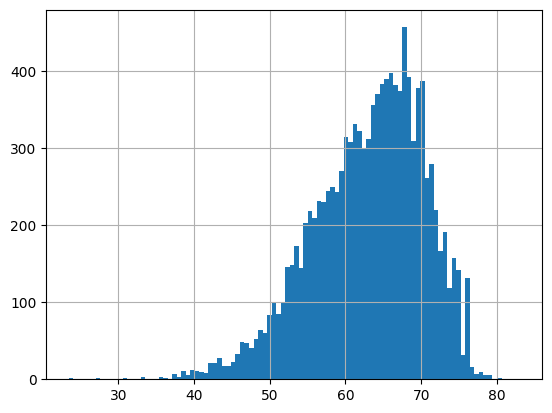

In [ ]:
tabla_regresion["ESTU_INSE_INDIVIDUAL"].hist(bins=100)


In [ ]:
tabla_regresion1 = tabla_regresion[
    (tabla_regresion['PUNT_C_NATURALES'] <= 100) &
    (tabla_regresion['PUNT_MATEMATICAS'] <= 100) &
    (tabla_regresion['PUNT_LECTURA_CRITICA'] <= 100) &
    (tabla_regresion['PUNT_SOCIALES_CIUDADANAS'] <= 100) &
    (tabla_regresion['PUNT_INGLES'] <= 100) &
    (tabla_regresion['ESTU_INSE_INDIVIDUAL'] <= 80)
]

tabla_regresion1.head(6)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
3,45,41,41,27,58.0,41.863163
4,53,55,41,56,69.0,51.223795
5,63,38,60,59,45.0,57.690401
6,69,60,59,51,50.0,39.984838
7,57,68,74,61,52.0,50.613232


In [ ]:
x = np.array(tabla_regresion1["PUNT_MATEMATICAS"]).reshape(-1, 1)
y = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]
trainx, testx, trainy, testy = train_test_split(x, y, test_size=0.2, random_state=0)
modelo_lineal0 = LinearRegression()
regresion0 = modelo_lineal0.fit(trainx, trainy)
pred_lineal0 = regresion0.predict(testx)

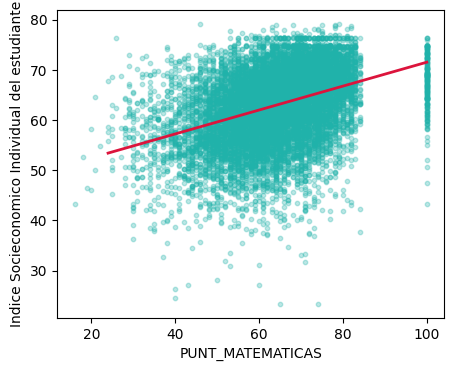

In [ ]:
plt.figure(figsize=(5, 4))
plt.scatter(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
            alpha=0.3, s=10, color='lightseagreen')
orden = np.argsort(testx.ravel())
plt.plot(testx.ravel()[orden], pred_lineal0[orden], linestyle='-', color='crimson', linewidth=2)
plt.xlabel("PUNT_MATEMATICAS")
plt.ylabel("Indice Socieconomico Individual del estudiante")
plt.show()  # Aqui se toman los datos de VALIDACIÓN (20%)

In [ ]:
x0 = np.array(tabla_regresion1["PUNT_MATEMATICAS"]).reshape(-1, 1)
y0 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]
modelo_lineal01 = LinearRegression()
regresion01 = modelo_lineal01.fit(x0, y0)
pred_lineal01 = regresion01.predict(x0)

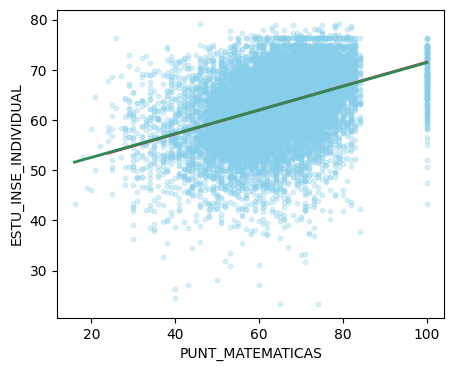

In [ ]:
orden2 = np.argsort(x0.ravel())
plt.figure(figsize=(5, 4))
plt.scatter(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
            alpha=0.3, s=10, color='skyblue')
plt.plot(testx.ravel()[orden], pred_lineal0[orden], linestyle='-', color='crimson', linewidth=2)
plt.plot(x0.ravel()[orden2], pred_lineal01[orden2], linestyle='-', color='seagreen', linewidth=2)
plt.xlabel("PUNT_MATEMATICAS")
plt.ylabel("ESTU_INSE_INDIVIDUAL")
plt.show() # Aqui tomamos TODOS los datos (100%)

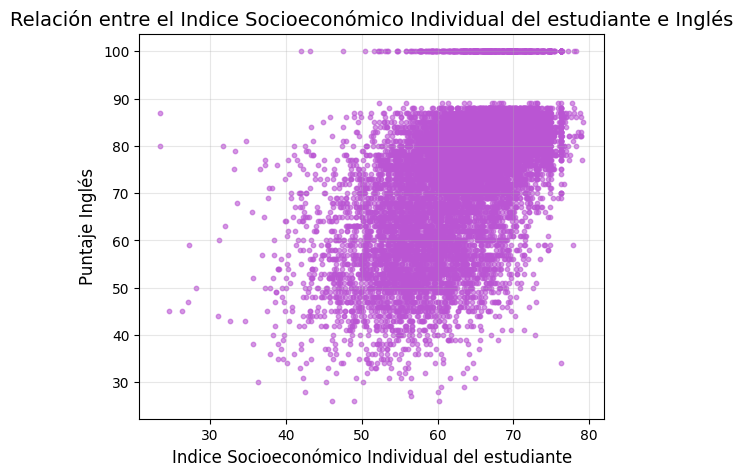

In [ ]:

plt.figure(figsize=(6, 5))

plt.scatter(
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
    tabla_regresion1["PUNT_INGLES"],
    color="mediumorchid",
    alpha=0.6,
    s=10
)

plt.title("Relación entre el Indice Socioeconómico Individual del estudiante e Inglés", fontsize=14)
plt.xlabel("Indice Socioeconómico Individual del estudiante", fontsize=12)
plt.ylabel("Puntaje Inglés", fontsize=12)

plt.grid(alpha=0.3)
plt.show()


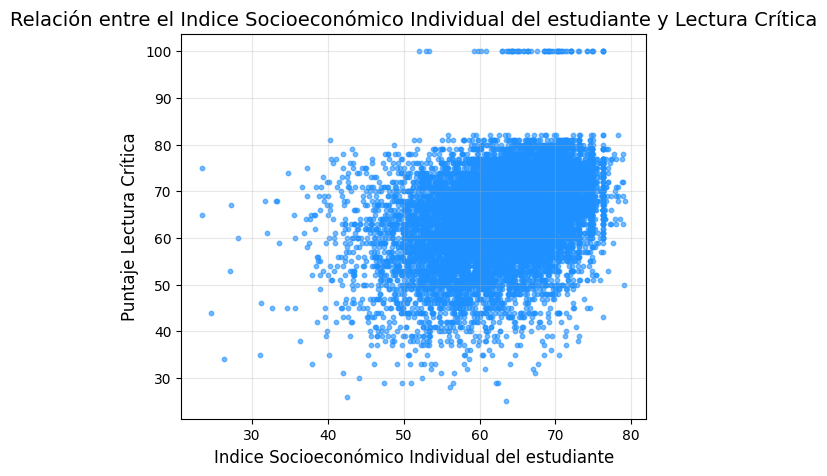

In [ ]:

plt.figure(figsize=(6, 5))

plt.scatter(
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
    tabla_regresion1["PUNT_LECTURA_CRITICA"],
    color="dodgerblue",
    alpha=0.6,
    s=10
)

plt.title("Relación entre el Indice Socioeconómico Individual del estudiante y Lectura Crítica", fontsize=14)
plt.xlabel("Indice Socioeconómico Individual del estudiante", fontsize=12)
plt.ylabel("Puntaje Lectura Crítica", fontsize=12)

plt.grid(alpha=0.3)
plt.show()

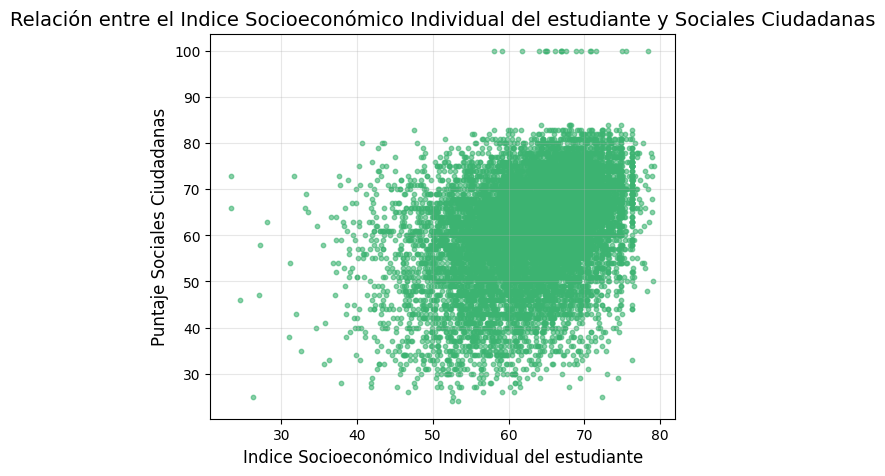

In [ ]:
plt.figure(figsize=(6, 5))

plt.scatter(
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
    tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"],
    color="mediumseagreen",
    alpha=0.6,
    s=10
)

plt.title("Relación entre el Indice Socioeconómico Individual del estudiante y Sociales Ciudadanas", fontsize=14)
plt.xlabel("Indice Socioeconómico Individual del estudiante", fontsize=12)
plt.ylabel("Puntaje Sociales Ciudadanas", fontsize=12)

plt.grid(alpha=0.3)
plt.show()

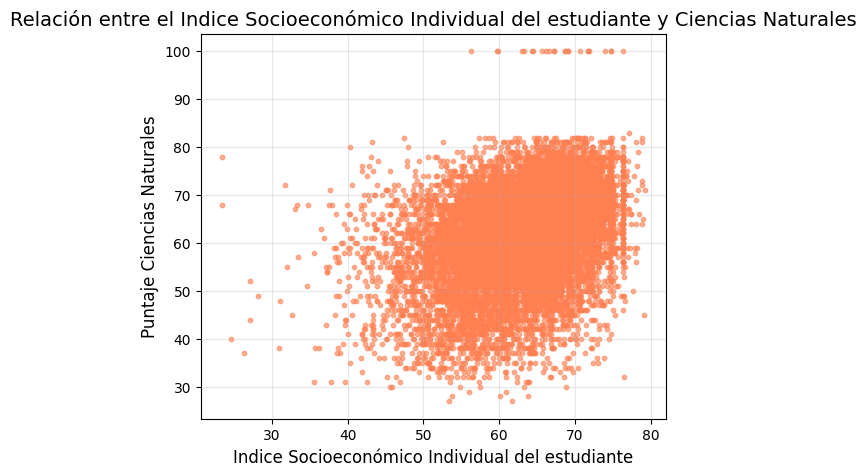

In [ ]:

plt.figure(figsize=(6, 5))

plt.scatter(
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
    tabla_regresion1["PUNT_C_NATURALES"],
    color="coral",
    alpha=0.6,
    s=10
)

plt.title("Relación entre el Indice Socioeconómico Individual del estudiante y Ciencias Naturales", fontsize=14)
plt.xlabel("Indice Socioeconómico Individual del estudiante", fontsize=12)
plt.ylabel("Puntaje Ciencias Naturales", fontsize=12)

plt.grid(alpha=0.3)
plt.show()

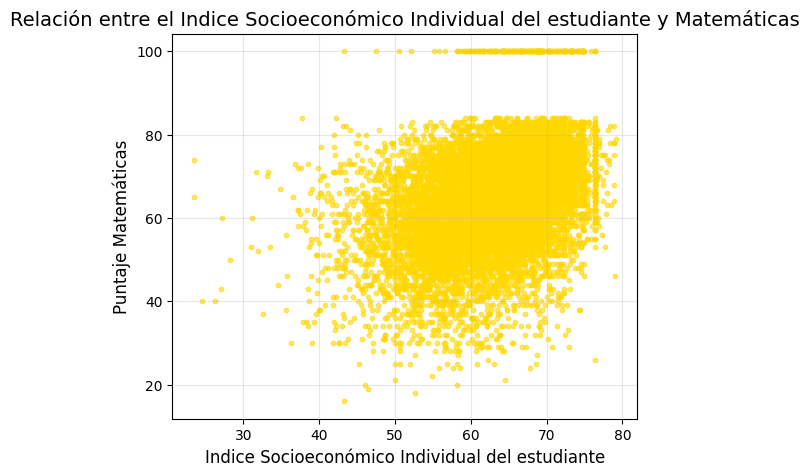

In [ ]:

plt.figure(figsize=(6, 5))

plt.scatter(
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
    tabla_regresion1["PUNT_MATEMATICAS"],
    color="gold",
    alpha=0.6,
    s=10
)

plt.title("Relación entre el Indice Socioeconómico Individual del estudiante y Matemáticas", fontsize=14)
plt.xlabel("Indice Socioeconómico Individual del estudiante", fontsize=12)
plt.ylabel("Puntaje Matemáticas", fontsize=12)

plt.grid(alpha=0.3)
plt.show()

In [ ]:


X = tabla_regresion1.drop(["ESTU_INSE_INDIVIDUAL"], axis=1)
Y = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=0)
trainX.head(5)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
143,57,60,52,54,75.0
3114,67,69,65,65,79.0
7299,66,68,60,62,73.0
5895,69,65,62,66,100.0
7118,77,100,80,77,100.0


In [ ]:
modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(trainX, trainY)
r2_lineal= regresion.score(testX, testY)
print("R² :", r2_lineal)

R² : 0.3081968646144112


In [ ]:

X1 = tabla_regresion1[['PUNT_LECTURA_CRITICA',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS',
                       'PUNT_INGLES']]

Y1 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train1X, test1X, train1Y, test1Y = train_test_split(
    X1, Y1,
    test_size = 0.2,
    random_state = 0
)

train1X.head(4)

,PUNT_LECTURA_CRITICA,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
143,57,52,54,75.0
3114,67,65,65,79.0
7299,66,60,62,73.0
5895,69,62,66,100.0


In [ ]:

modelo_lineal1 = LinearRegression()
regresion1 = modelo_lineal1.fit(train1X, train1Y)
r2_lineal1 = regresion1.score(test1X, test1Y)
print("R² Nodelo 1 :", r2_lineal1)

R² Nodelo 1 : 0.3091639949914916


In [ ]:

X2 = tabla_regresion1[['PUNT_MATEMATICAS',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS',
                       'PUNT_INGLES']]

Y2 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train2X, test2X, train2Y, test2Y = train_test_split(
    X2, Y2,
    test_size = 0.2,
    random_state = 0
)
modelo_lineal2 = LinearRegression()
regresion2 = modelo_lineal2.fit(train2X, train2Y)
r2_lineal2 = regresion2.score(test2X, test2Y)
print("R² Nodelo :", r2_lineal2)


R² Nodelo : 0.30719150369119463


In [ ]:
X3= tabla_regresion1[['PUNT_MATEMATICAS',
                       'PUNT_LECTURA_CRITICA',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS']]

Y3 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train3X, test3X, train3Y, test3Y = train_test_split(
    X3, Y3,
    test_size = 0.2,
    random_state = 0
)
modelo_lineal3 = LinearRegression()
regresion3 = modelo_lineal3.fit(train3X, train3Y)
r2_lineal3 = regresion3.score(test3X, test3Y)
print("R² Nodelo 3 :", r2_lineal3)

R² Nodelo 3 : 0.1605263009386998


In [ ]:
XY, Z = tabla_regresion1[["PUNT_INGLES", "PUNT_LECTURA_CRITICA"]], tabla_regresion1["ESTU_INSE_INDIVIDUAL"]
trainXY, testXY, trainZ, testZ = train_test_split(XY, Z, test_size=0.2, random_state=0)
trainXY.head(4)

,PUNT_INGLES,PUNT_LECTURA_CRITICA
143,75.0,57
3114,79.0,67
7299,73.0,66
5895,100.0,69


In [ ]:
modelo1 = LinearRegression()
modelo1.fit(trainXY, trainZ)

LinearRegression()

In [ ]:
modelo1.score(testXY, testZ)

0.30793521819855896

In [ ]:
array = modelo1.coef_
array

array([0.29204812, 0.00268171])

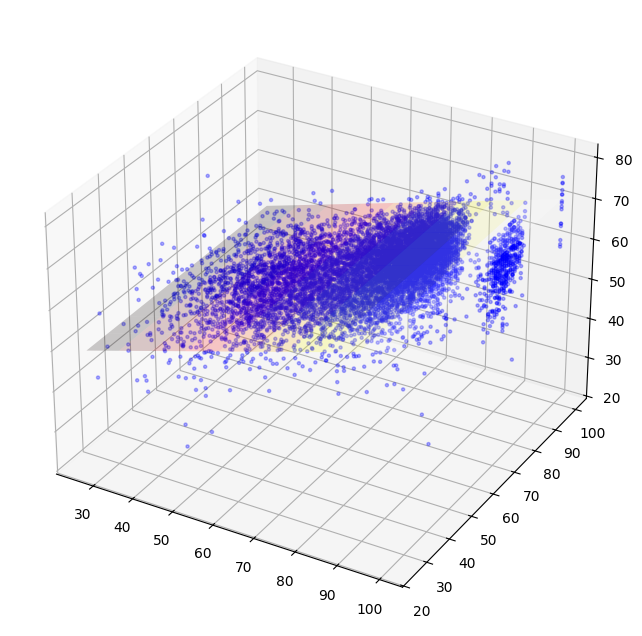

In [ ]:
fig = plt.figure(figsize=((10,8)))
ax = fig.add_subplot(projection='3d')
xx, yy = np.meshgrid(
    np.linspace(tabla_regresion1["PUNT_INGLES"].min(),
                tabla_regresion1["PUNT_INGLES"].max(), num=10),
    np.linspace(tabla_regresion1["PUNT_LECTURA_CRITICA"].min(),
                tabla_regresion1["PUNT_LECTURA_CRITICA"].max(), num=10)
)
plano_reg = array[0]*xx + array[1]*yy + modelo1.intercept_
ax.plot_surface(xx, yy, plano_reg, alpha=0.2, cmap='hot')
ax.scatter(trainXY["PUNT_INGLES"], trainXY["PUNT_LECTURA_CRITICA"], trainZ, c='blue', s=5, alpha=0.3)


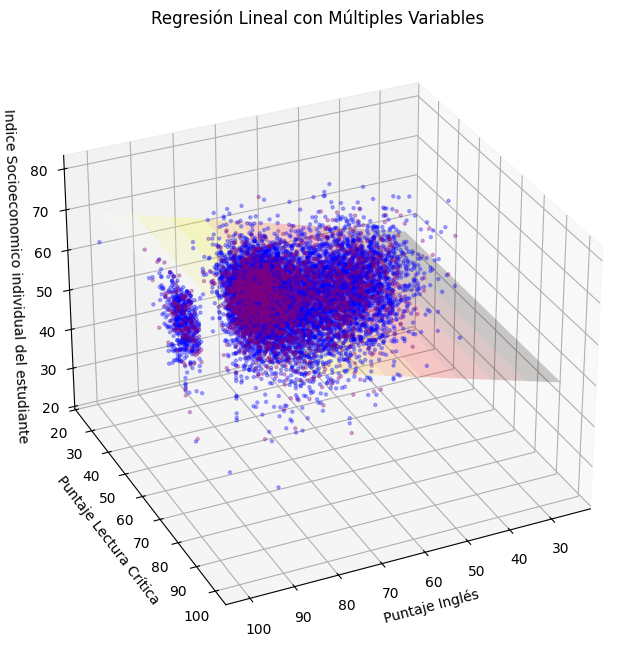

In [ ]:
fig = plt.figure(figsize=((10,8)))
ax = fig.add_subplot(projection='3d')
xx, yy = np.meshgrid(
    np.linspace(tabla_regresion1["PUNT_INGLES"].min(),
                tabla_regresion1["PUNT_INGLES"].max(), num=10),
    np.linspace(tabla_regresion1["PUNT_LECTURA_CRITICA"].min(),
                tabla_regresion1["PUNT_LECTURA_CRITICA"].max(), num=10)
)
plano_reg = array[0]*xx + array[1]*yy + modelo1.intercept_
ax.plot_surface(xx, yy, plano_reg, alpha=0.2, cmap='hot')
ax.scatter(trainXY["PUNT_INGLES"], trainXY["PUNT_LECTURA_CRITICA"], trainZ, c='blue', s=5, alpha=0.3)
ax.scatter(testXY["PUNT_INGLES"], testXY["PUNT_LECTURA_CRITICA"], testZ, c='purple', s=5, alpha=0.3)
ax.view_init(elev=30., azim=65)
ax.set_xlabel('Puntaje Inglés')
ax.set_ylabel('Puntaje Lectura Crítica')
ax.set_zlabel('Indice Socioeconomico individual del estudiante')
ax.set_title('Regresión Lineal con Múltiples Variables')
plt.show()

In [ ]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 100,100,100,100,100), max_iter=500, random_state=0, activation = "relu", solver = "adam", learning_rate = "invscaling")
mlp_reg.fit(trainX, trainY)

MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100, 100),
             learning_rate='invscaling', max_iter=500, random_state=0)

In [ ]:
mlp_reg.score(testX, testY)

0.31100800090317426

In [ ]:
X.head(4)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
0,100,83,77,77,87.0
3,45,41,41,27,58.0
4,53,55,41,56,69.0
5,63,38,60,59,45.0


In [ ]:
no_obs = np.array([[60, 70,85,90,52]])

print('Se espera que el Indice socioeconomico indivual del estudiante sea de', mlp_reg.predict(no_obs),
      'bajo el perceptrón multicapa y',
      modelo_lineal.predict(no_obs),
      'bajo el modelo de regresión lineal múltiple.')

Se espera que el Indice socioeconomico indivual del estudiante sea de [70.60296368] bajo el perceptrón multicapa y [57.18554855] bajo el modelo de regresión lineal múltiple.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:

# Matemáticas vs Índice Socioeconómico
pearson_corr = np.corrcoef(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr, _ = spearmanr(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr, _ = kendalltau(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Lectura Crítica vs Índice Socioeconómico
pearson_corr1 = np.corrcoef(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr1, _ = spearmanr(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr1, _ = kendalltau(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Ciencias Naturales vs Índice Socioeconómico
pearson_corr2 = np.corrcoef(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr2, _ = spearmanr(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr2, _ = kendalltau(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Sociales y Ciudadanas vs Índice Socioeconómico
pearson_corr3 = np.corrcoef(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr3, _ = spearmanr(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr3, _ = kendalltau(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Inglés vs Índice Socioeconómico
pearson_corr4 = np.corrcoef(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr4, _ = spearmanr(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr4, _ = kendalltau(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

print("Los coeficientes de correlación de Pearson, Spearman y Kendall son respectivamente:")
print(f"Matemáticas: {pearson_corr}, {spearman_corr}, {kendall_corr}")
print(f"Lectura Crítica: {pearson_corr1}, {spearman_corr1}, {kendall_corr1}")
print(f"Ciencias Naturales: {pearson_corr2}, {spearman_corr2}, {kendall_corr2}")
print(f"Sociales y Ciudadanas: {pearson_corr3}, {spearman_corr3}, {kendall_corr3}")
print(f"Inglés: {pearson_corr4}, {spearman_corr4}, {kendall_corr4}")

Los coeficientes de correlación de Pearson, Spearman y Kendall son respectivamente:
Matemáticas: 0.37683736133080836, 0.39400899187464034, 0.27113110155972353
Lectura Crítica: 0.3548249041293775, 0.357601630521943, 0.24638305472022304
Ciencias Naturales: 0.35988523658908733, 0.36473331372387097, 0.2505203000174778
Sociales y Ciudadanas: 0.357710332535216, 0.3627552242779997, 0.24907781368459858
Inglés: 0.5511896092082889, 0.5656611211298977, 0.3957316498242702


In [ ]:
# Estudiantes con índice socioeconómico alto (cola derecha del histograma)
tabla_regresion2 = tabla_regresion1[
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"] >= 65
]
tabla_regresion2.head(10)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
11,58,61,54,43,63.0,71.737309
13,63,68,72,64,65.0,74.580643
14,67,74,70,70,69.0,69.897661
15,72,76,74,65,75.0,68.645524
17,61,56,58,53,66.0,74.143164
18,59,64,56,59,58.0,72.064645
19,74,100,70,73,80.0,68.597046
20,54,63,61,57,65.0,69.332582
21,80,78,77,82,82.0,67.325226


In [ ]:

# Predice con el MLP
X_no = tabla_regresion2.drop(['ESTU_INSE_INDIVIDUAL'], axis=1)
mlp_reg.predict(X_no)

array([66.44291529, 59.74493071, 59.42906623, ..., 67.25789151,
       68.78335448, 64.67077849])

In [ ]:

tabla_regresion2["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no)
tabla_regresion2


/tmp/ipykernel_36782/3149512807.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_regresion2["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no)


,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,66.442915
11,58,61,54,43,63.0,59.744931
13,63,68,72,64,65.0,59.429066
14,67,74,70,70,69.0,60.420485
15,72,76,74,65,75.0,62.824144
...,...,...,...,...,...,...
12690,61,53,64,60,84.0,65.559682
12693,71,75,73,71,82.0,66.740127
12695,73,69,73,77,85.0,67.257892
12698,74,76,71,72,87.0,68.783354


In [ ]:

# icfes_connan: estudiantes con INSE faltante pero puntajes completos
icfes_connan = datos_icfes[
    (datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
]
print(f"Estudiantes con INSE faltante: {len(icfes_connan)}")

Estudiantes con INSE faltante: 849


In [ ]:
X_imputar = icfes_connan[['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']]

icfes_imputado = icfes_connan.copy()
icfes_imputado['ESTU_INSE_INDIVIDUAL'] = mlp_reg.predict(X_imputar)

print("Estadísticas del INSE imputado:")
print(icfes_imputado['ESTU_INSE_INDIVIDUAL'].describe().round(2))
icfes_imputado[['PUNT_MATEMATICAS', 'PUNT_LECTURA_CRITICA', 'ESTU_INSE_INDIVIDUAL']].head(10)

Estadísticas del INSE imputado:
count    849.00
mean      61.66
std        4.74
min       49.77
25%       57.84
50%       62.43
75%       65.30
max       72.90
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


,PUNT_MATEMATICAS,PUNT_LECTURA_CRITICA,ESTU_INSE_INDIVIDUAL
35,52,67,57.459162
63,62,63,57.432119
84,36,44,54.042274
183,65,54,56.632838
201,40,57,58.750559
205,60,58,59.172282
221,53,59,61.515336
232,55,41,57.659810
257,78,72,64.142288
258,71,74,67.169379


In [87]:
# Estudiantes con alto lectura crítica y bajo inglés
caso_interes = icfes_imputado[
    (icfes_imputado['PUNT_LECTURA_CRITICA'] > 65) &
    (icfes_imputado['PUNT_INGLES'] < 55)
]

print("Cantidad de estudiantes en el caso:", len(caso_interes))

caso_interes[['PUNT_LECTURA_CRITICA', 'PUNT_INGLES', 'ESTU_INSE_INDIVIDUAL']].head(10)

Cantidad de estudiantes en el caso: 10


,PUNT_LECTURA_CRITICA,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
35,67,52.0,57.459162
539,66,52.0,56.301589
653,69,50.0,55.931995
2408,67,53.0,58.082236
2661,68,54.0,56.817739
2915,68,51.0,56.143465
4742,69,46.0,54.871703
5317,68,41.0,55.218995
5591,66,53.0,60.169917
12411,67,47.0,55.589554


In [88]:
print("Estadísticas del INSE en este grupo:")
print(caso_interes['ESTU_INSE_INDIVIDUAL'].describe().round(2))

Estadísticas del INSE en este grupo:
count    10.00
mean     56.66
std       1.58
min      54.87
25%      55.68
50%      56.22
75%      57.30
max      60.17
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


In [89]:
print("Promedio INSE general:")
print(icfes_imputado['ESTU_INSE_INDIVIDUAL'].mean().round(2))

print("Promedio INSE caso específico:")
print(caso_interes['ESTU_INSE_INDIVIDUAL'].mean().round(2))

Promedio INSE general:
61.66
Promedio INSE caso específico:
56.66
